In [1]:
import pandas as pd
from glob import glob 
import numpy as np
import os

from matplotlib import pyplot as plt
import seaborn as sns


def fill_time_range(df, freq='1min', dt_col='datetime'):
    """
    df의 dt_col에서 최소~최대 시간 범위의 연속 구간을 freq 간격으로 생성해서,
    해당 구간의 DataFrame과 merge하여 빈 row를 채운다.
    """
    full_range = pd.date_range(df[dt_col].min(), df[dt_col].max(), freq=freq)
    return pd.merge(
        pd.DataFrame({dt_col: full_range}),
        df,
        on=dt_col,
        how='left'
    )


data_paths = sorted(glob(os.path.join('..','..','..','data','rs_series','*')))
data_paths

['../../../data/rs_series/goes_mag.csv',
 '../../../data/rs_series/goes_proton.csv',
 '../../../data/rs_series/goes_xrs.csv',
 '../../../data/rs_series/omni_1hour.csv',
 '../../../data/rs_series/omni_1min.csv',
 '../../../data/rs_series/omni_5min.csv']

In [2]:
proton_df = pd.read_csv(data_paths[1], engine = 'pyarrow')
xrs_df = pd.read_csv(data_paths[2], engine = 'pyarrow')

In [3]:
proton_df = fill_time_range(proton_df, freq='1min', dt_col='datetime')
xrs_df = fill_time_range(xrs_df, freq='1min', dt_col='datetime')

In [4]:
proton_df.columns

Index(['datetime', 'satellite', 'proton_flux_gt1mev', 'proton_flux_gt5mev',
       'proton_flux_gt10mev', 'proton_flux_gt30mev', 'proton_flux_gt50mev',
       'proton_flux_gt60mev', 'proton_flux_gt100mev', 'proton_flag'],
      dtype='str')

In [5]:
proton_df.datetime.diff().value_counts()

datetime
0 days 00:00:00    3382560
0 days 00:01:00    2868479
Name: count, dtype: int64

In [63]:
proton_df.proton_flag.value_counts()

Series([], Name: count, dtype: int64)

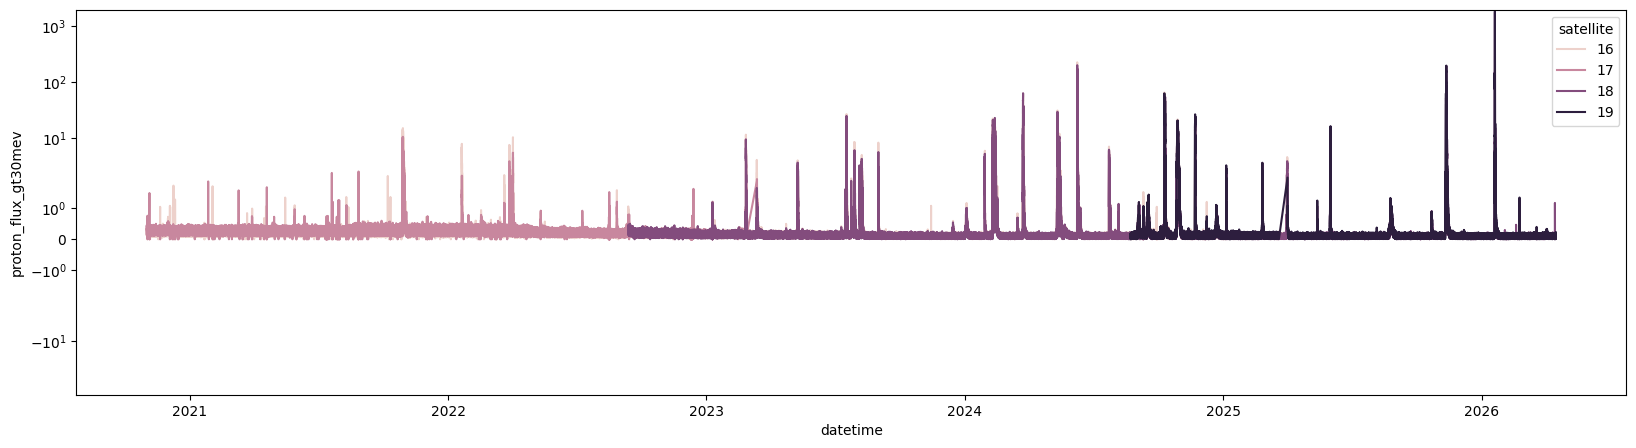

In [26]:
fig, ax = plt.subplots(figsize=(20, 5))
sns.lineplot(data=proton_df, x='datetime', y='proton_flux_gt30mev', hue = 'satellite', ax = ax)
ax.set_yscale('symlog')

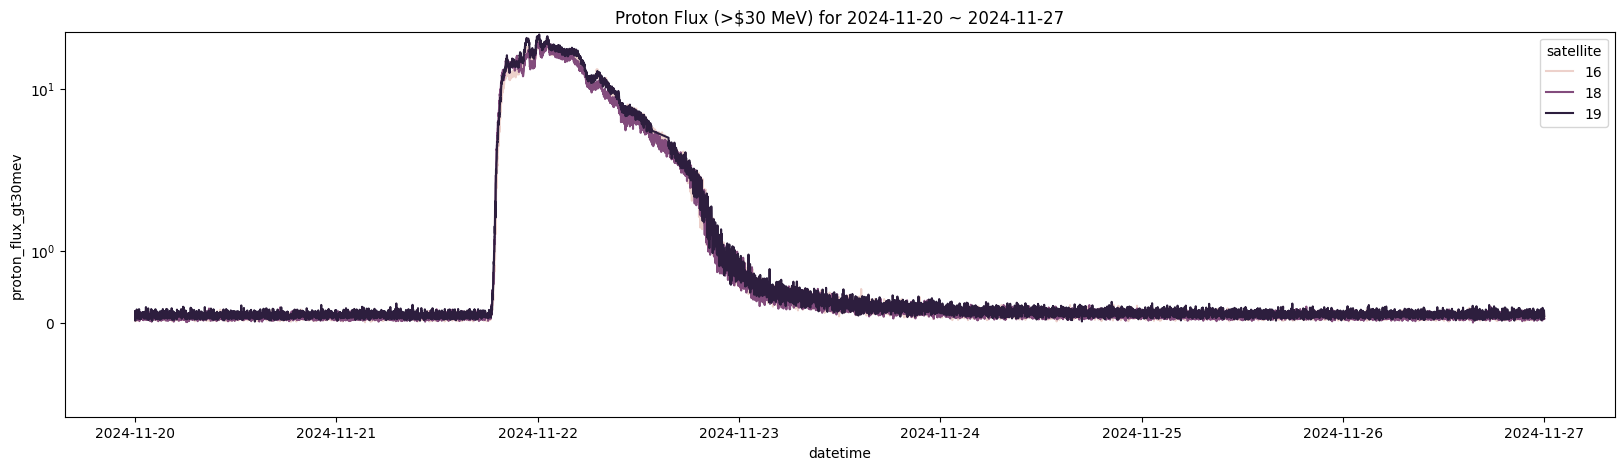

In [61]:
# 예시: 연도와 월, 일을 지정하여 7일간 데이터 플롯
import datetime

# 예시 입력: 연도, 월, 일
year = 2024
month = 11
day = 20

start_date = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")
end_date = start_date + pd.Timedelta(days=7)

mask = (proton_df['datetime'] >= start_date) & (proton_df['datetime'] < end_date)
plot_df = proton_df[mask]

fig, ax = plt.subplots(figsize=(20, 5))
sns.lineplot(data=plot_df, x='datetime', y='proton_flux_gt30mev', hue='satellite', ax=ax)
ax.set_yscale('symlog')
ax.set_title(f"Proton Flux (>$30 MeV) for {start_date.date()} ~ {end_date.date()}")
plt.show()

In [10]:
proton_df.min()

datetime                2020-11-01 00:00:00
satellite                                16
proton_flux_gt1mev                      0.0
proton_flux_gt5mev                      0.0
proton_flux_gt10mev                     0.0
proton_flux_gt30mev                     0.0
proton_flux_gt50mev                     0.0
proton_flux_gt60mev                     0.0
proton_flux_gt100mev                    0.0
proton_flag                             NaN
dtype: object

In [12]:
count_sat = proton_df.groupby('datetime')['satellite'].nunique()

In [40]:
count_sat.reset_index()

,datetime,satellite
0,2020-11-01 00:00:00,2
1,2020-11-01 00:01:00,2
2,2020-11-01 00:02:00,2
3,2020-11-01 00:03:00,2
4,2020-11-01 00:04:00,2
...,...,...
2868475,2026-04-15 23:55:00,2
2868476,2026-04-15 23:56:00,2
2868477,2026-04-15 23:57:00,2
2868478,2026-04-15 23:58:00,2


<Axes: xlabel='datetime', ylabel='satellite'>

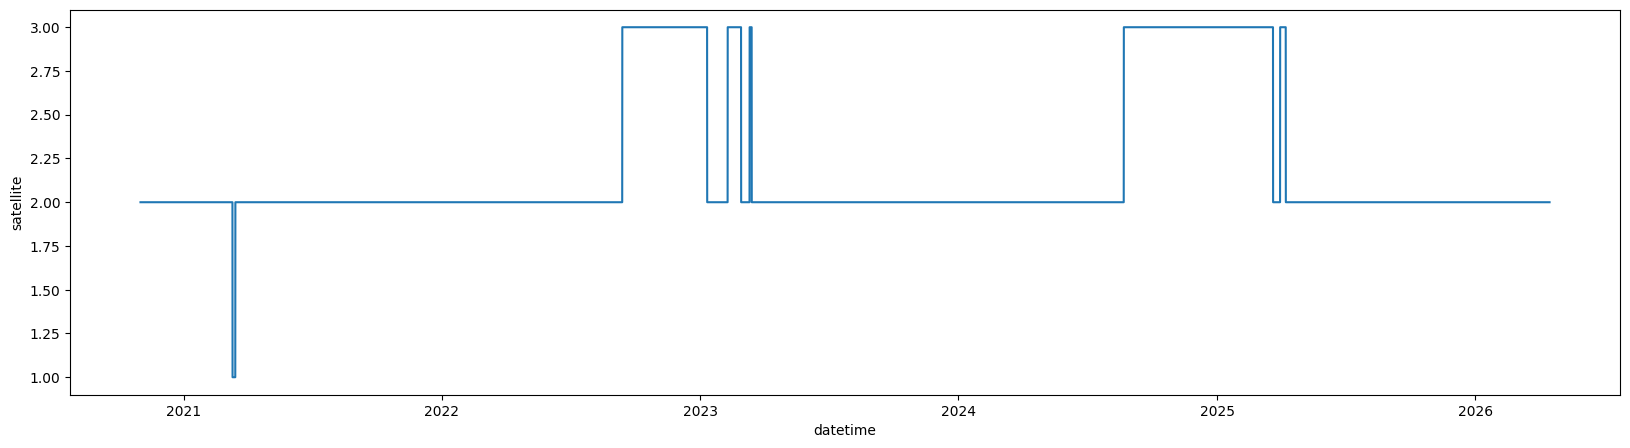

In [41]:
fig, ax = plt.subplots(figsize=(20, 5))
sns.lineplot(data=count_sat.reset_index(), x='datetime', y='satellite', ax = ax)